In [2]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import time

In [3]:
df = pd.read_csv('cleaned_autos.csv')
df

,dateCrawled,name,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,lastSeen,car_age,price_in_thousands
0,2016-03-17,GOLF 4 1 4 3TÜRER,test,hatchback,2001,manual,75.0,golf,150.0,6,gasoline,volkswagen,no,2016-03-17,2016-03-17,15.0,1.500000
1,2016-03-31,Skoda Fabia 1.4 TDI PD Classic,test,hatchback,2008,manual,69.0,fabia,90.0,7,diesel,skoda,no,2016-03-31,2016-04-06,8.0,3.600000
2,2016-04-04,BMW 316i e36 Limousine Bastlerfahrzeug Ex...,test,sedan,1995,manual,102.0,3er,150.0,10,gasoline,bmw,yes,2016-04-04,2016-04-06,21.0,0.650000
3,2016-04-01,Peugeot 206 CC 110 Platinum,test,cabrio,2004,manual,109.0,2_reihe,150.0,8,gasoline,peugeot,no,2016-04-01,2016-04-05,12.0,2.200000
4,2016-03-21,VW Derby Bj 80 Scheunenfund,test,sedan,1980,manual,50.0,andere,40.0,7,gasoline,volkswagen,no,2016-03-21,2016-03-25,36.0,6.204583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260738,2016-03-19,turbo defekt,control,sedan,2004,manual,225.0,leon,150.0,5,gasoline,seat,yes,2016-03-19,2016-03-19,12.0,3.200000
260739,2016-03-27,Opel Zafira 1.6 Elegance TÜV 12/16,control,bus,2000,manual,0.0,zafira,150.0,3,gasoline,opel,no,2016-03-27,2016-03-29,16.0,1.150000
260740,2016-03-05,Smart smart leistungssteigerung 100ps,test,cabrio,2000,automatic,101.0,fortwo,125.0,3,gasoline,smart,no,2016-03-05,2016-03-11,16.0,1.199000
260741,2016-03-19,Volkswagen Multivan T4 TDI 7DC UY2,test,bus,1996,manual,102.0,transporter,150.0,3,diesel,volkswagen,no,2016-03-19,2016-04-07,20.0,9.200000


In [4]:
df = df.drop(columns=['dateCrawled', 'dateCreated', 'lastSeen', 'name', 'monthOfRegistration'])


In [5]:
y = df['vehicleType']
x = df.drop(columns=['vehicleType'])

In [6]:
le_encoder = LabelEncoder()
for column in x.columns:
    if x[column].dtype == 'object':
        x[column] = le_encoder.fit_transform(x[column])

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, class_weight='balanced', random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model2 = GradientBoostingClassifier(n_estimators=100, max_depth=10, random_state=42)
model2.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=10, random_state=42)

In [8]:
y_pred = model2.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 77.00%
               precision    recall  f1-score   support

          bus       0.87      0.90      0.88      4962
       cabrio       0.81      0.74      0.77      3708
        coupe       0.70      0.56      0.62      2913
    hatchback       0.89      0.89      0.89     11900
        other       0.18      0.10      0.13       375
        sedan       0.69      0.74      0.72     15257
station wagon       0.70      0.69      0.69     10669
          suv       0.88      0.88      0.88      2365

     accuracy                           0.77     52149
    macro avg       0.71      0.69      0.70     52149
 weighted avg       0.77      0.77      0.77     52149



In [10]:
importances = pd.Series(model2.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)
importances

model                 0.360782
powerPS               0.252748
brand                 0.132779
price_in_thousands    0.090436
fuelType              0.052911
car_age               0.039401
yearOfRegistration    0.038384
kilometer             0.018248
gearbox               0.006381
abtest                0.004257
notRepairedDamage     0.003673
dtype: float64

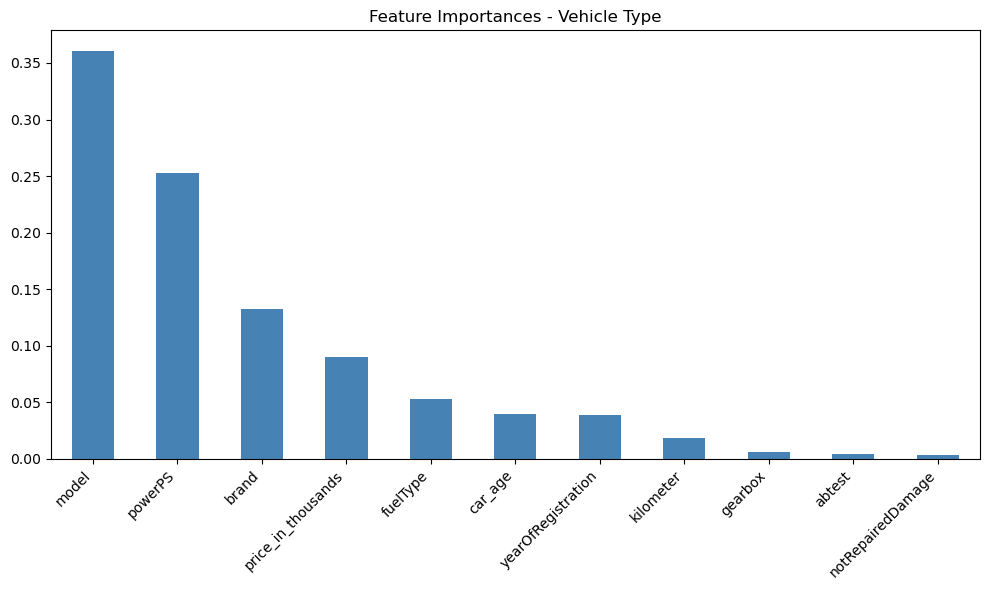

In [11]:
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importances - Vehicle Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
important_features = importances[importances > 0.05].index
print("Selected features:", list(important_features))

Selected features: ['model', 'powerPS', 'brand', 'price_in_thousands', 'fuelType']


In [13]:
x_important = x[important_features]
x_train2, x_test2, y_train2, y_test2 = train_test_split(x_important, y, test_size=0.2, random_state=42)

In [ ]:
model3 = GradientBoostingClassifier(n_estimators=100, max_depth=10, random_state=42)
model3.fit(x_train2, y_train2)



In [18]:
y_pred = model2.predict(x_test2)
print(f"Accuracy: {accuracy_score(y_test2, y_pred) * 100:.2f}%")
print(classification_report(y_test2, y_pred))

Accuracy: 66.80%
               precision    recall  f1-score   support

          bus       0.80      0.71      0.76      4962
       cabrio       0.85      0.36      0.51      3708
        coupe       0.65      0.30      0.41      2913
    hatchback       0.80      0.87      0.83     11900
        other       0.80      0.01      0.02       375
        sedan       0.54      0.75      0.63     15257
station wagon       0.63      0.55      0.59     10669
          suv       0.90      0.58      0.70      2365

     accuracy                           0.67     52149
    macro avg       0.75      0.52      0.56     52149
 weighted avg       0.69      0.67      0.66     52149

